<a href="https://colab.research.google.com/github/AadyaAgarwal01/Credit_Risk/blob/main/Credit_Risk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup and Data Loading

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

In [36]:
path = kagglehub.dataset_download("itssuru/loan-data")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

df.columns = df.columns.str.strip()

Using Colab cache for faster access to the 'loan-data' dataset.


In [37]:
df['int.rate'] = df['int.rate'].fillna(df['int.rate'].mean())

df['installment'] = df['installment'].fillna(df['installment'].median())

print("Cleaning complete.")

Cleaning complete.


In [38]:
df['int.rate'] = df['int.rate'].fillna(df['int.rate'].mean())

df['installment'] = df['installment'].fillna(df['installment'].median())


print("Cleaning complete.")

Cleaning complete.


Exploratory Data Analysis (EDA)

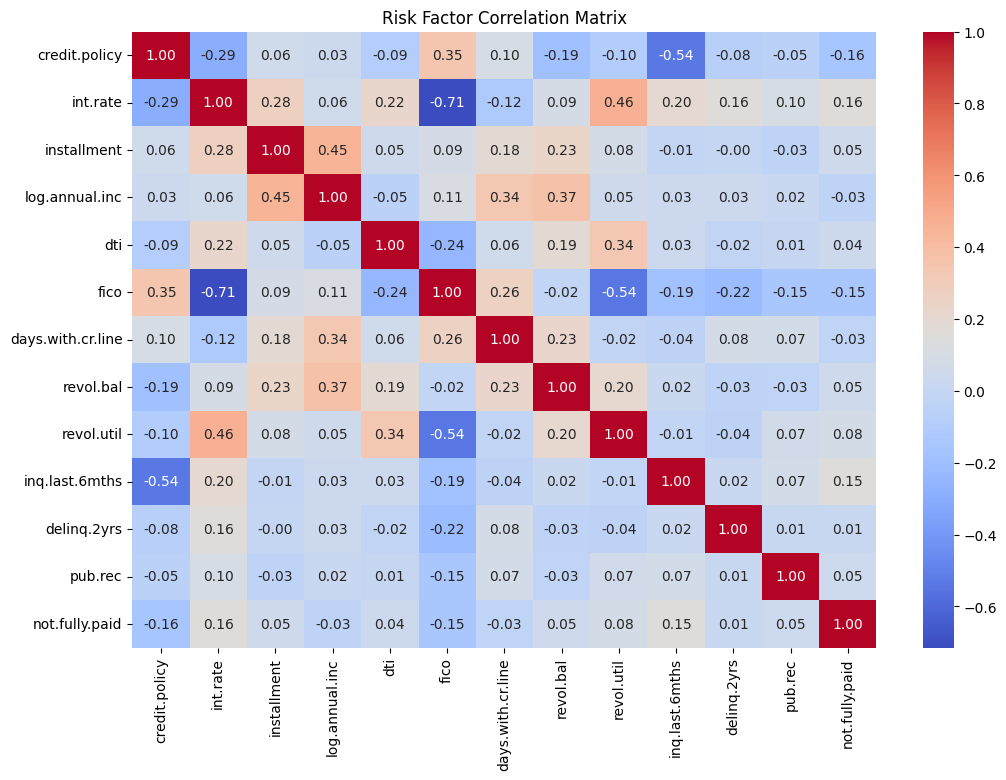

In [39]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Risk Factor Correlation Matrix")
plt.show()

# Pre-Processing (Encoding & Splitting)

In [40]:
y = df['not.fully.paid']

X_raw = df.drop('not.fully.paid', axis=1)

X = pd.get_dummies(X_raw, drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handling Imbalance (SMOTE)

In [41]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87      1611
           1       0.29      0.24      0.26       305

    accuracy                           0.78      1916
   macro avg       0.57      0.56      0.57      1916
weighted avg       0.77      0.78      0.78      1916



# Performance Visualization (ROC Curve)

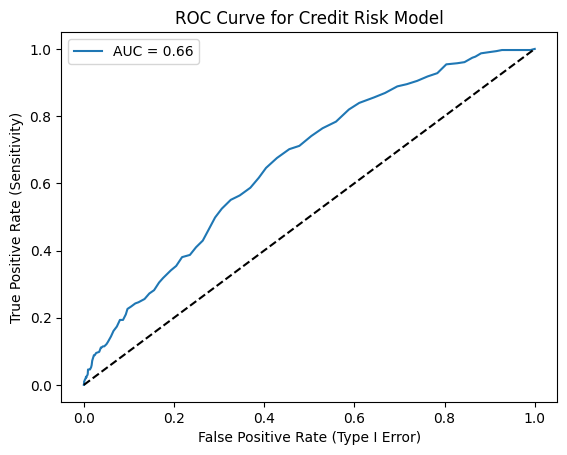

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (Type I Error)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Credit Risk Model')
plt.legend()
plt.show()

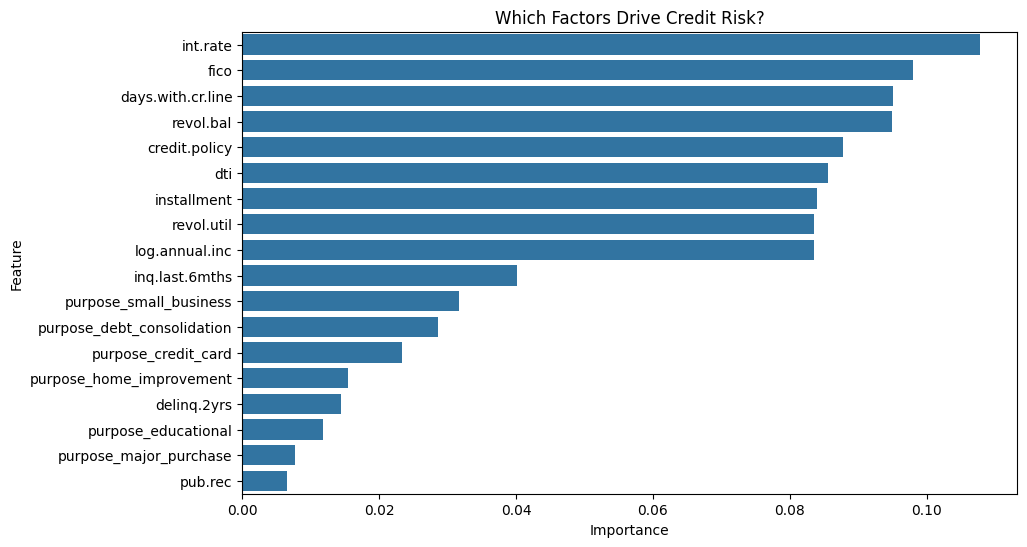

In [44]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Which Factors Drive Credit Risk?')
plt.show()

In [45]:
def predict_loan_approval(new_data):

    new_df = pd.DataFrame([new_data])

    new_data_encoded = pd.get_dummies(new_df).reindex(columns=X.columns, fill_value=0)

    prediction = model.predict(new_data_encoded)[0]
    probability = model.predict_proba(new_data_encoded)[0][1]

    print("--- BANK DECISION ---")
    if prediction == 1:
        print(f"RESULT: REJECTED (Risk Probability: {probability:.2%})")
        print("Reason: High likelihood of default.")
    else:
        print(f"RESULT: APPROVED (Risk Probability: {probability:.2%})")
        print("Reason: Meets safety criteria.")

In [46]:
sample_applicant = {
    'credit.policy': 1,
    'int.rate': 0.07,
    'installment': 150,
    'log.annual.inc': 11.5,
    'dti': 10.5,
    'fico': 780,
    'days.with.cr.line': 5000,
    'revol.bal': 2000,
    'revol.util': 10.5,
    'inq.last.6mths': 0,
    'delinq.2yrs': 0,
    'pub.rec': 0,
    'purpose': 'credit_card'
}

predict_loan_approval(sample_applicant)

--- BANK DECISION ---
RESULT: APPROVED (Risk Probability: 1.00%)
Reason: Meets safety criteria.
